We are an analyst for RUSH, a footwear brand. The company stores its data in three tables. We are tasked with analyzing the sales data for trends and insights that will help the company leadership understand the market.

In [ ]:
#load the tables into pandas and combine them
import pandas as pd
table_sales = pd.read_csv('/content/TABLE_SALES_885.csv')
table_retailer = pd.read_csv('/content/TABLE_RETAILER_885.csv')
#products table is pipe-delimited
table_products = pd.read_csv('/content/TABLE_PRODUCTS_885.csv', sep = "|")
#combine the tables using merge. combine on common identifiers
#merge sales and retailer tables on "RETAILER_ID".
sales_retailer = pd.merge(table_sales, table_retailer, on = "RETAILER_ID", how = "left")
#merge sales_retailer and product tables on "PRODUCT_ID"
combined_tables = pd.merge(sales_retailer, table_products, on = "PRODUCT_ID", how = "left")
combined_tables.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


In [ ]:
#inspect the data
combined_tables.info()
#convert units_sold to integer
combined_tables['UNITS_SOLD'] = pd.to_numeric(combined_tables['UNITS_SOLD'], errors='coerce')
#find number of rows with null values
combined_tables.isnull().sum()#there are two null values in price_per_unit and units_sold

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          10271 non-null  int64  
 1   RETAILER_ID       10271 non-null  object 
 2   INVOICE_DATE      10271 non-null  object 
 3   MONTH             10271 non-null  int64  
 4   DAY               10271 non-null  int64  
 5   YEAR              10271 non-null  int64  
 6   PRODUCT_ID        10271 non-null  int64  
 7   PRICE_PER_UNIT    10269 non-null  float64
 8   UNITS_SOLD        10271 non-null  object 
 9   OPERATING_MARGIN  10271 non-null  float64
 10  SALES_METHOD      10271 non-null  object 
 11  RETAILER          10270 non-null  object 
 12  REGION            10270 non-null  object 
 13  STATE             10270 non-null  object 
 14  CITY              10270 non-null  object 
 15  PRODUCT_NAME      10271 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,2
OPERATING_MARGIN,0


In [ ]:
#drop null values
combined_tables = combined_tables.dropna()
combined_tables.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


In [ ]:
#Find the number of rows with duplicate values across all rows. This is not as useful as checking for duplicates across specific categories
combined_tables.duplicated().sum()

np.int64(0)

In [ ]:
#generate descriptive stats to check for erroneous values. Max "PRICE_PER_UNIT" & "STD" are erroneous
combined_tables.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN
count,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000
mean,4970.660822,6.456361,14.620592,2020.873368,80.031171,54.577635,246.578999,0.426375
std,2770.242222,3.462033,7.300022,0.332576,50.666469,986.618030,211.875799,0.096035
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.000000,0.100000
25%,2569.250000,3.000000,9.000000,2021.000000,30.000000,35.000000,100.000000,0.350000
50%,5135.500000,6.000000,14.000000,2021.000000,120.000000,45.000000,173.000000,0.420000
75%,7235.750000,9.000000,20.000000,2021.000000,130.000000,55.000000,325.000000,0.500000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,1275.000000,0.800000


In [ ]:
#check for erroneous values in object datatype
#loop over each column counting unique values
categories = list(combined_tables.select_dtypes(include=['object']).columns)
for column in categories:
    print(column)
    print(combined_tables[[column]].value_counts())
    #retailer_id has an erroneous 99999999
    #sales method misspells outlet

RETAILER_ID
RETAILER_ID
W00SARLI       432
W00SFLOR       378
W00STEHO       324
W00WORPO       216
W00WNELA       216
              ... 
S00MNEOM         8
K00MMIMI         8
S00MILCH         8
W00MOHCO         8
W00NMAPO         8
Name: count, Length: 106, dtype: int64
INVOICE_DATE
INVOICE_DATE
1/17/2021       88
11/17/2021      83
12/16/2021      81
1/10/2021       80
4/17/2021       79
                ..
10/10/2020       2
9/18/2020        2
9/19/2020        2
4/2/2020         1
4/8/2020         1
Name: count, Length: 724, dtype: int64
SALES_METHOD
SALES_METHOD
Online          5416
Outlet          3092
In-store        1738
Ootlet            20
Name: count, dtype: int64
RETAILER
RETAILER     
West Gear        2822
Foot Locker      2637
Sports Direct    2087
Kohl's           1030
Amazon            947
Walmart           743
Name: count, dtype: int64
REGION
REGION   
West         2448
Northeast    2430
South        2105
Midwest      1870
Southeast    1413
Name: count, dtype: int64
STAT

In [ ]:
#fix retailer_id and sales_method misspelling
#replace 'ootlet'
combined_tables['SALES_METHOD'] = combined_tables['SALES_METHOD'].replace('Ootlet','Outlet')
#remove the row with 999999 retailer id
combined_tables = combined_tables[combined_tables['RETAILER_ID'] != '999999999']

In [ ]:
#check for erroneous values in int and float columns
#loop over each column counting unique values
categories = list(combined_tables.select_dtypes(include=['int64','float64']).columns)
for column in categories:
    print(column)
    print(combined_tables[[column]].value_counts())#there is an erroneous price per unit value of 99,999.

ORDER_ID
ORDER_ID
9141        2
9140        2
9139        2
5310        2
6799        2
           ..
3220        1
3221        1
3222        1
3223        1
3214        1
Name: count, Length: 9643, dtype: int64
MONTH
MONTH
1        919
8        901
4        889
9        872
5        868
10       862
3        854
11       850
2        837
7        824
12       816
6        774
Name: count, dtype: int64
DAY
DAY
17     743
10     660
12     493
24     473
13     469
6      453
11     446
19     417
16     413
18     409
23     409
9      390
20     378
21     367
3      358
22     339
5      339
8      329
14     311
4      298
7      288
15     254
25     228
26     222
2      210
27     131
1       97
28      96
29      91
30      91
31      64
Name: count, dtype: int64
YEAR
YEAR
2021    8966
2020    1300
Name: count, dtype: int64
PRODUCT_ID
PRODUCT_ID
30            1714
140           1714
120           1712
130           1710
20            1708
40            1708
Name: count, dtype: i

In [ ]:
#impute the erroneous price per unit value with median value
median_unit_price = combined_tables['PRICE_PER_UNIT'].median()
combined_tables['PRICE_PER_UNIT'] = combined_tables['PRICE_PER_UNIT'].replace(99999.0,median_unit_price)

In [ ]:
combined_tables.describe() #This shows maximum "PRICE_PER_UNIT" & "STD" are now reasonable

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN
count,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000,10266.000000
mean,4970.660822,6.456361,14.620592,2020.873368,80.031171,44.841223,246.578999,0.426375
std,2770.242222,3.462033,7.300022,0.332576,50.666469,14.791031,211.875799,0.096035
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.000000,0.100000
25%,2569.250000,3.000000,9.000000,2021.000000,30.000000,35.000000,100.000000,0.350000
50%,5135.500000,6.000000,14.000000,2021.000000,120.000000,45.000000,173.000000,0.420000
75%,7235.750000,9.000000,20.000000,2021.000000,130.000000,55.000000,325.000000,0.500000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,110.000000,1275.000000,0.800000


In [ ]:
#check for outliers
#create a function to calculate inner quartile range
def iqr_outliers(df,column):
  q1= df[column].quantile(.25)
  q3=df[column].quantile(.75)
  iqr=q3-q1
#calculate outliers
  lower_threshold=q1 -1.5*iqr
  upper_threshold=q3+1.5*iqr
  outliers = (df[column] < lower_threshold) | (df[column] > upper_threshold)
  #count number of outliers
  return outliers.sum()

In [ ]:
#select numerical dataype columns
numerical = list(combined_tables.select_dtypes(include =['int64','float64']).columns)
#print the outliers in each numerical category by calling the iqr function
for column in numerical:
    print(f'{column}:{iqr_outliers(combined_tables,column)}') # the iqr for "YEAR"can be ingored because there are only two years. There is a small amount of outliers in 'price_per_unit' and "operating_margin" which can be deemed as reasonable for retail goods

ORDER_ID:0
MONTH:0
DAY:0
YEAR:1300
PRODUCT_ID:0
PRICE_PER_UNIT:84
UNITS_SOLD:680
OPERATING_MARGIN:31


<Axes: xlabel='UNITS_SOLD', ylabel='Count'>

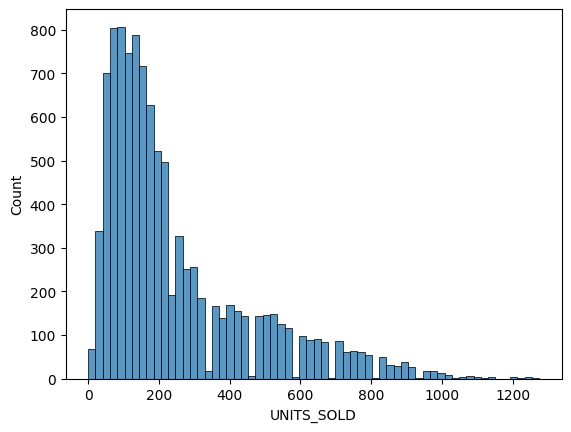

In [ ]:
#check units sold outliers with a histogram
import seaborn as sns
sns.histplot(combined_tables['UNITS_SOLD']) #shows some reasonable outliers above 1000 units sold so it doesnt need to be clipped

In [ ]:
#create new column calculating product sales
combined_tables['sales_dollars'] = combined_tables['PRICE_PER_UNIT'] * combined_tables['UNITS_SOLD']
combined_tables.head(1)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,sales_dollars
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200.0,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,60000.0


In [ ]:
#Check for duplicates across date, product_id, and sales_dollars. This indicates error such as immediate return or cancelation and should be dropped
duplicates = combined_tables.duplicated(subset=['INVOICE_DATE', 'PRODUCT_ID', 'sales_dollars'])
print(f" The Number of duplicates is :{duplicates.sum()}")

 The Number of duplicates is :749


In [ ]:
#drop duplicates with same date, product id and sales amount
combined_tables = combined_tables.drop_duplicates(subset=['INVOICE_DATE', 'PRODUCT_ID', 'sales_dollars'])

In [ ]:
#what product had the highest sales in dollars in 2021?
year_filter_2021 = combined_tables[combined_tables['YEAR']==2021]

In [ ]:
#What product had the highest sales in 2021?
#group the products by name and sum their sales totals
product_sales_2021 = (year_filter_2021.groupby(['PRODUCT_ID','PRODUCT_NAME'], as_index=False)['sales_dollars'].sum())
#sort
top_product = product_sales_2021.sort_values('sales_dollars', ascending=False)
print(top_product.loc[0])

PRODUCT_ID                          20
PRODUCT_NAME     Men's Street Footwear
sales_dollars               22003524.0
Name: 0, dtype: object


/tmp/ipython-input-1919085663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_product['sales_dollars'], y=top_product['PRODUCT_NAME'], palette = 'deep')


Text(0.5, 0, 'Sales (Tens of Millions of Dollars)')

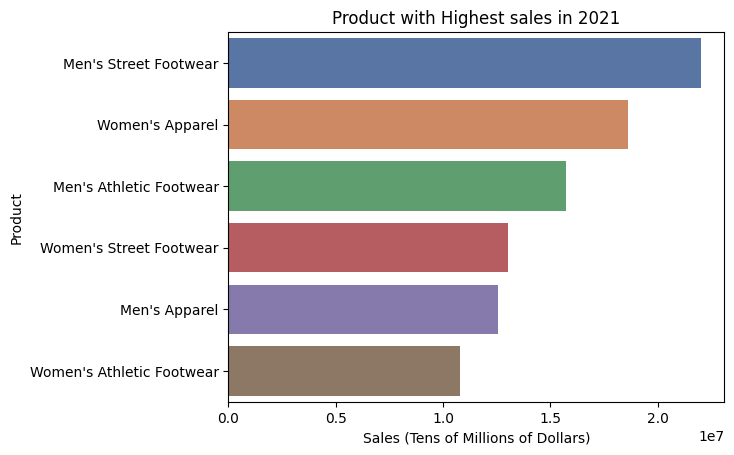

In [ ]:
#plot barchart showing product sales
sns.barplot(x=top_product['sales_dollars'], y=top_product['PRODUCT_NAME'], palette = 'deep')
plt.title('Product with Highest sales in 2021')
plt.ylabel('Product')
plt.xlabel('Sales (Tens of Millions of Dollars)')

What state had the highest sales of Women's products in 2021?

In [ ]:
#filter the data to only contain data of women's products in 2021
women_2021 = year_filter_2021[(year_filter_2021['PRODUCT_NAME'].str.contains('Women'))]
women_2021.head(1)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,sales_dollars
5162,167,A00NMAPO,1/2/2021,1,2,2021,120,65.0,750.0,0.4,Outlet,Amazon,Northeast,Maine,Portland,Women's Street Footwear,48750.0


In [ ]:
#group the data by state and sum their sales
women_sales_by_state = women_2021.groupby('STATE')['sales_dollars'].sum()
#sort values
women_sales_by_state_sorted = women_sales_by_state.sort_values(ascending=False)
#print(women_sales_by_state_sorted)
state_w = women_sales_by_state_sorted.index[0]
sales_w = women_sales_by_state_sorted.iloc[0]
print(f"The state with the most women's product sales in 2021 is: {state_w}: ${sales_w}")

The state with the most women's product sales in 2021 is: Maine: $2176301.0


/tmp/ipython-input-2119286897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_w.values,y=top_10_w.index, palette='rocket')
/tmp/ipython-input-2119286897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10_w.values, y=bottom_10_w.index,palette='gray')


Text(0.5, 0, 'Sales in Dollars ($)')

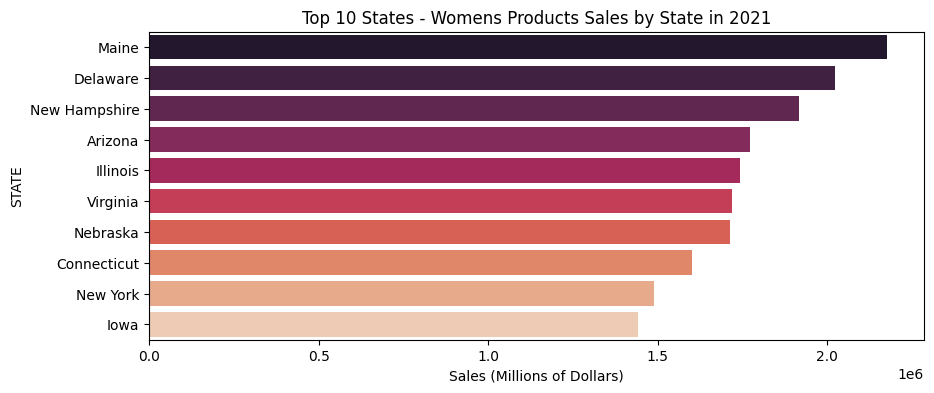

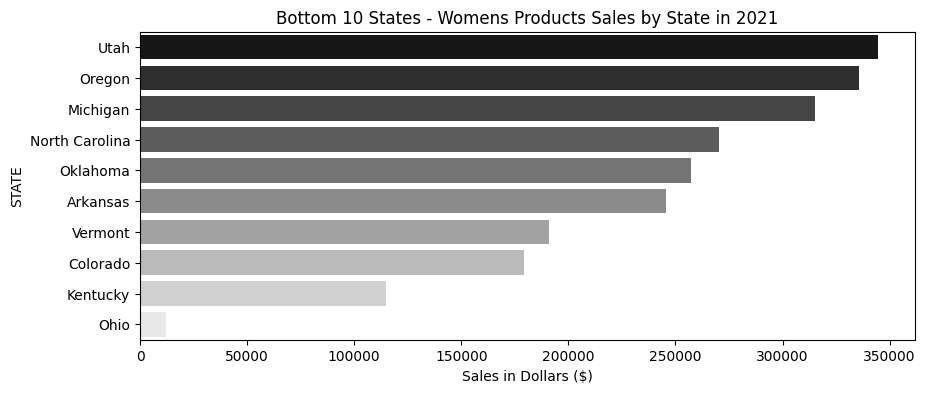

In [ ]:
#split it into top 10 and bottom 10 because all 50 is difficult to read
#plot top 10
bottom_10_w = women_sales_by_state_sorted.tail(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_10_w.values,y=top_10_w.index, palette='rocket')
plt.title('Top 10 States - Womens Products Sales by State in 2021')
plt.xlabel('Sales (Millions of Dollars)')

#plott bottom 10
plt.figure(figsize=(10,4))
bottom_10_w = women_sales_by_state_sorted.tail(10)
sns.barplot(x=bottom_10_w.values, y=bottom_10_w.index,palette='gray')
plt.title('Bottom 10 States - Womens Products Sales by State in 2021')
plt.xlabel('Sales in Dollars ($)')

In [ ]:
#what state had the highest sales of men's products in 2021
#create a 'men's products' filter using the data already filtered to contain 2021 data
men_2021 = year_filter_2021[(year_filter_2021['PRODUCT_NAME'].str.contains('Men'))]
men_2021.head(3)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,sales_dollars
28,171,A00NMAPO,1/6/2021,1,6,2021,20,60.0,975.0,0.40,Outlet,Amazon,Northeast,Maine,Portland,Men's Street Footwear,58500.0
29,177,A00NMAPO,1/12/2021,1,12,2021,20,60.0,1025.0,0.35,Outlet,Amazon,Northeast,Maine,Portland,Men's Street Footwear,61500.0
30,183,A00NMAPO,1/18/2021,1,18,2021,20,65.0,975.0,0.35,Outlet,Amazon,Northeast,Maine,Portland,Men's Street Footwear,63375.0


In [ ]:
#group the data by state
men_sales_by_state = men_2021.groupby('STATE')['sales_dollars'].sum()
men_sales_by_state_sorted = men_sales_by_state.sort_values(ascending=False)
#print(women_sales_by_state_sorted)
state_m = men_sales_by_state_sorted.index[0]
sales_m = men_sales_by_state_sorted.iloc[0]
print(f"The state with the most women's product sales in 2021 is: {state_m}: ${sales_m}")

The state with the most women's product sales in 2021 is: Delaware: $2334300.0


/tmp/ipython-input-2112170455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_m.values,y=top_10_m.index, palette='mako')
/tmp/ipython-input-2112170455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10_m.values, y=bottom_10_m.index,palette='gray')


Text(0.5, 0, 'Sales in Dollars ($)')

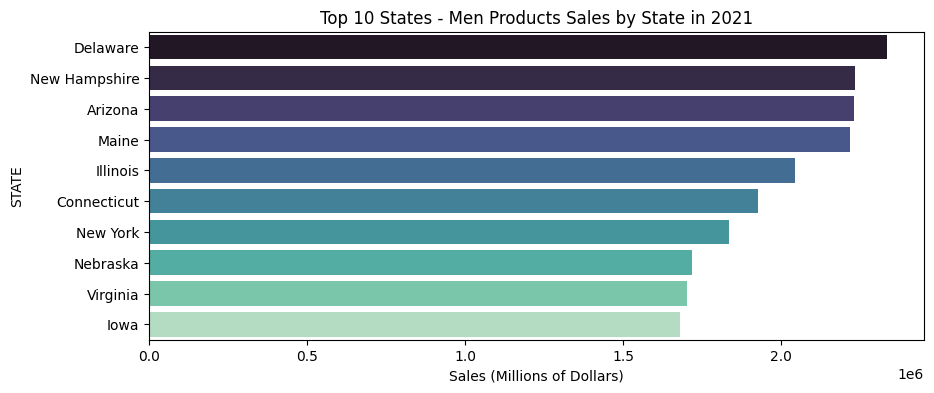

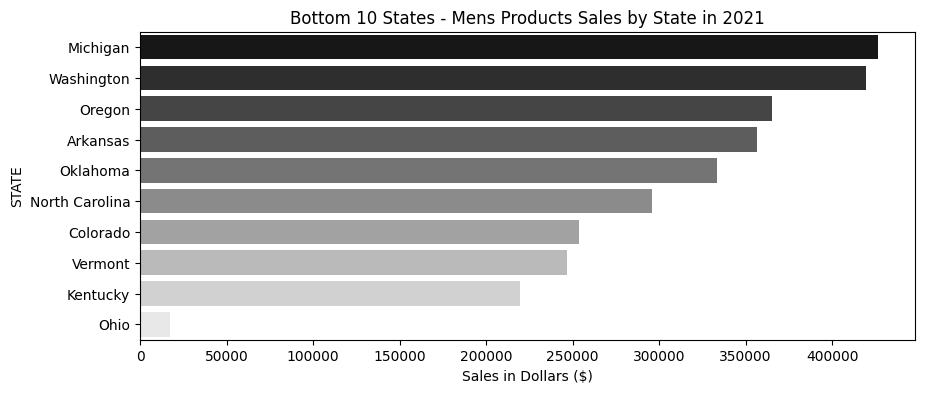

In [ ]:
#split it into top 10 and bottom 10 because all 50 is difficult to read

#plot top 10
top_10_m = men_sales_by_state_sorted.head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_10_m.values,y=top_10_m.index, palette='mako')
plt.title('Top 10 States - Men Products Sales by State in 2021')
plt.xlabel('Sales (Millions of Dollars)')

#plott bottom 10
bottom_10_m = men_sales_by_state_sorted.tail(10)
plt.figure(figsize=(10,4))
sns.barplot(x=bottom_10_m.values, y=bottom_10_m.index,palette='gray')
plt.title('Bottom 10 States - Mens Products Sales by State in 2021')
plt.xlabel('Sales in Dollars ($)')

In [ ]:
#What retailer purchased the most units in 2021?
Units_Sold_2021 = year_filter_2021.groupby('RETAILER')['UNITS_SOLD'].sum()
retailer_units_sorted_2021 = Units_Sold_2021.sort_values(ascending=False)
#print(retailer_units_sorted_2021)
max_retailer_2021 = retailer_units_sorted_2021.index[0]
max_retailer_units_2021 = retailer_units_sorted_2021.iloc[0]
print(f"The retailer that purchased the most units in 2021 is: {max_retailer_2021} with {max_retailer_units_2021} units")

The retailer that purchased the most units in 2021 is: Foot Locker with 1052060.0 units


/tmp/ipython-input-1620735300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retailer_units_sorted_2021.index,y=retailer_units_sorted_2021.values, palette = 'deep')


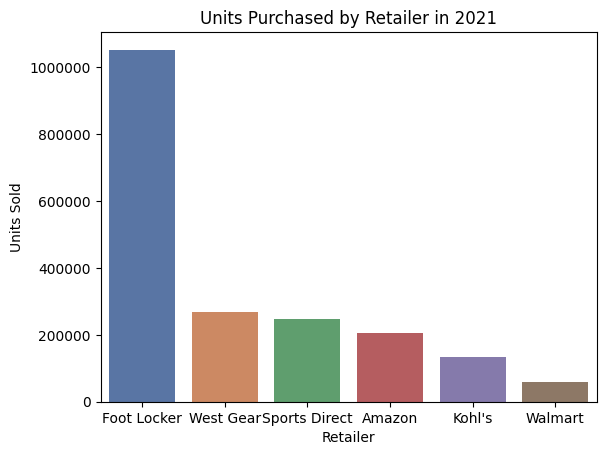

In [ ]:
#plot barchart showing max reatiler units purchased
sns.barplot(x=retailer_units_sorted_2021.index,y=retailer_units_sorted_2021.values, palette = 'deep')
plt.title('Units Purchased by Retailer in 2021')
plt.ylabel('Units Sold')
plt.xlabel('Retailer')
#remove scientific notation labeling because the quantity is less than one million
plt.ticklabel_format(style='plain', axis = 'y')

In [ ]:
#What retailer purchased the most units in 2020
#filter the data tables for 2020
year_filter_2020 = combined_tables[combined_tables['YEAR'] == 2020 ]
#group by retailer and sum the yearly total units purchased
Units_Sold_2020 = year_filter_2020.groupby('RETAILER')['UNITS_SOLD'].sum()
#sort the yearly total units purchased by retailer
retailer_units_sorted_2020 = Units_Sold_2020.sort_values(ascending=False)
#print(retailer_units_sorted_2020)
max_retailer_2020 = retailer_units_sorted_2020.index[0]
max_retailer_units_2020 = retailer_units_sorted_2020.iloc[0]
print(f"The retailer that purchased the most units in 2021 is {max_retailer_2020} : {max_retailer_units_2020} units")

The retailer that purchased the most units in 2021 is Amazon : 316880.0 units


/tmp/ipython-input-3210819220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retailer_units_sorted_2020.index,y=retailer_units_sorted_2020.values, palette ='gray')


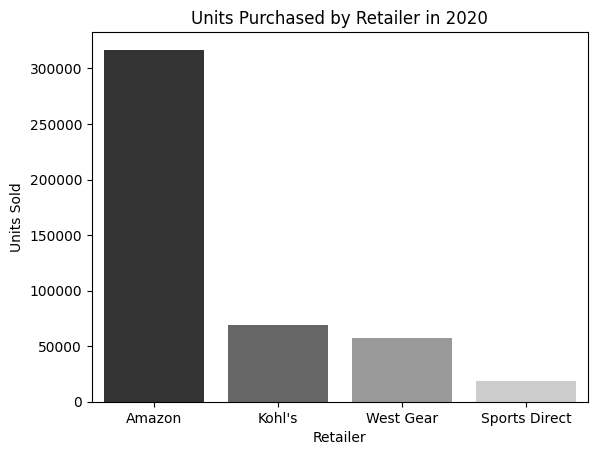

In [ ]:
#plot bar chart showing max reatiler units purchased
sns.barplot(x=retailer_units_sorted_2020.index,y=retailer_units_sorted_2020.values, palette ='gray')
plt.title('Units Purchased by Retailer in 2020')
plt.ylabel('Units Sold')
plt.xlabel('Retailer')
#remove scientific notation labeling
plt.ticklabel_format(style='plain', axis = 'y')

In [ ]:
#find seasonality trends by finding monthly sales
#convert invoice date to datetime dtype to get month
combined_tables['INVOICE_DATE'] = pd.to_datetime(combined_tables['INVOICE_DATE'])
#create new column containing month
combined_tables['MONTH'] = combined_tables['INVOICE_DATE'].dt.month
#group by by month and sum sales total
monthly_sales = combined_tables.groupby('MONTH')['sales_dollars'].sum()
#sort monthly sales
monthly_sales_sorted = monthly_sales.sort_values(ascending=False)
#print(monthly_sales_sorted)
#categorieze the monthly into four season and their sales totals
winter_sales = monthly_sales.loc[[12,1,2]].sum()
spring_sales = monthly_sales.loc[[3,4,5]].sum()
summer_sales = monthly_sales.loc[[6,7,8]].sum()
fall_sales = monthly_sales.loc[[9,10,11]].sum()
print(f" Winter sales total ${winter_sales}\n Spring sales total ${spring_sales}\n Summer sales total is ${summer_sales}\n Fall sales total is ${fall_sales}")


 Winter sales total $28808990.0
 Spring sales total $27661443.0
 Summer sales total is $32822892.0
 Fall sales total is $27503573.0


([<matplotlib.axis.XTick at 0x7bd8e8e63590>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

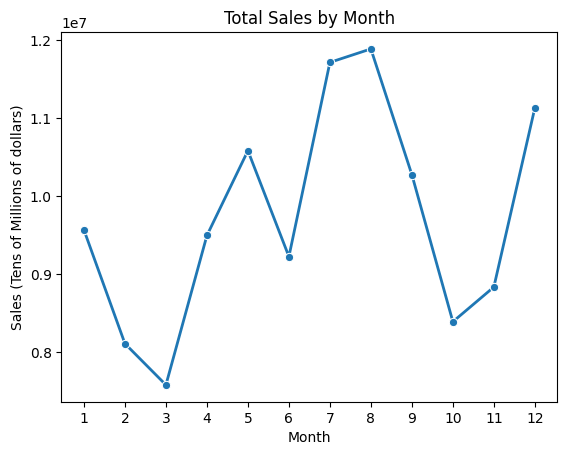

In [ ]:
#Create a lineplot to show monthly trend of sales
#reset index to plot months and sales dollars
monthly_sales_df = monthly_sales.reset_index()
sns.lineplot(data=monthly_sales_df, x='MONTH', y='sales_dollars', marker = 'o',linewidth=2)
#label the plot
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales (Tens of Millions of dollars)')
#set x axis range to show every month value
plt.xticks(range(1,13))

/tmp/ipython-input-3040989220.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x =seasons, y =seasonal_sales, palette ='deep')


Text(0.5, 0, 'Season')

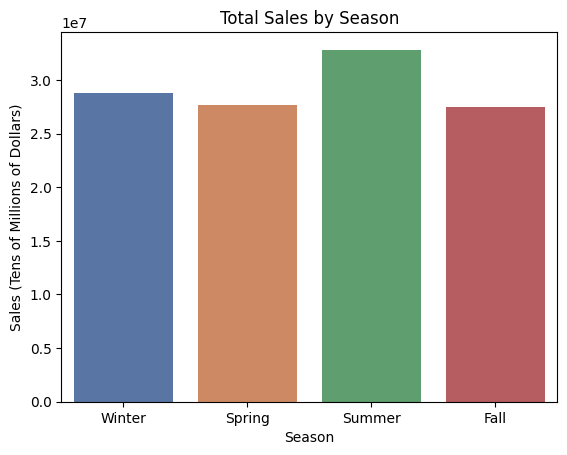

In [ ]:
#plot the seasonal sales data
seasonal_sales = [winter_sales, spring_sales, summer_sales, fall_sales]
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
sns.barplot(x =seasons, y =seasonal_sales, palette ='deep')
plt.title('Total Sales by Season')
plt.ylabel('Sales (Tens of Millions of Dollars)')
plt.xlabel('Season')

<Axes: xlabel='SEASON', ylabel='sales_dollars'>

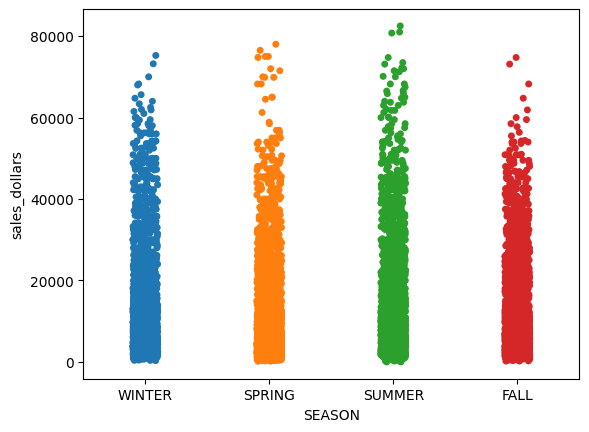

In [ ]:
#make a swarmplot to show all datapoints instead of totals to give a different vizualization
#create a new season column grouping the data using months
combined_tables.loc[combined_tables['MONTH'].isin([12,1,2]),'SEASON'] = 'WINTER'
combined_tables.loc[combined_tables['MONTH'].isin([3,4,5]),'SEASON'] = 'SPRING'
combined_tables.loc[combined_tables['MONTH'].isin([6,7,8]),'SEASON'] = 'SUMMER'
combined_tables.loc[combined_tables['MONTH'].isin([9,10,11]),'SEASON'] = 'FALL'
#make stripplot because data overlaps too much for swarmplot
sns.stripplot(data = combined_tables, x ='SEASON' ,y ='sales_dollars',hue ='SEASON')

REGION
Northeast    38635538.0
Midwest      28518403.0
West         24689168.0
Southeast    14641011.0
South        10312778.0
Name: sales_dollars, dtype: float64


/tmp/ipython-input-3329774440.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales_sorted.index,y=region_sales_sorted.values, palette ='deep')


<Axes: title={'center': 'Total Sales by Region'}, xlabel='Region', ylabel='Sales (Tens of Millions of Dollars)'>

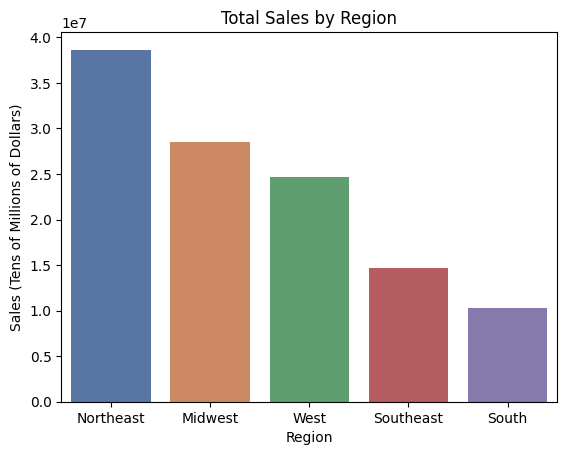

In [ ]:
#find total sales by region
region_sales = combined_tables.groupby('REGION')['sales_dollars'].sum()
region_sales_sorted = region_sales.sort_values(ascending=False)
print(region_sales_sorted)
plt.title('Total Sales by Region')
plt.ylabel('Sales (Tens of Millions of Dollars)')
plt.xlabel('Region')
sns.barplot(x=region_sales_sorted.index,y=region_sales_sorted.values, palette ='deep')

/tmp/ipython-input-1437245901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_tables, x="REGION",y="sales_dollars", palette = "deep")


<Axes: xlabel='REGION', ylabel='sales_dollars'>

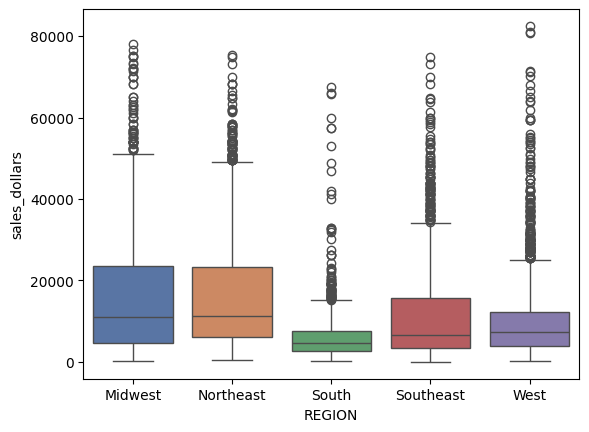

In [ ]:
#plot boxplot of sales data by region
sns.boxplot(data=combined_tables, x="REGION",y="sales_dollars", palette = "deep")

                  OPERATING_MARGIN  PRICE_PER_UNIT  UNITS_SOLD  sales_dollars
OPERATING_MARGIN          1.000000       -0.133617   -0.303019      -0.302211
PRICE_PER_UNIT           -0.133617        1.000000    0.252330       0.522865
UNITS_SOLD               -0.303019        0.252330    1.000000       0.922553
sales_dollars            -0.302211        0.522865    0.922553       1.000000


<Axes: >

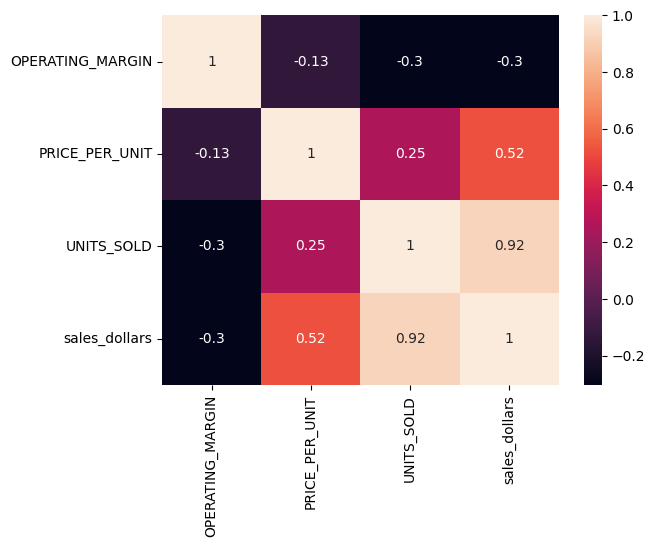

In [ ]:
#find the correlation between operating margin, price per unit, units sold and sales
corr_data = ['OPERATING_MARGIN','PRICE_PER_UNIT','UNITS_SOLD','sales_dollars']
correlation = combined_tables[corr_data].corr()
print(correlation)
#show correlation metrics in a heatmap
sns.heatmap(correlation,annot=True)

/tmp/ipython-input-4038052456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_method_sales.index,y=sales_method_sales.values, palette ='deep')


Text(0.5, 0, 'Sales Method')

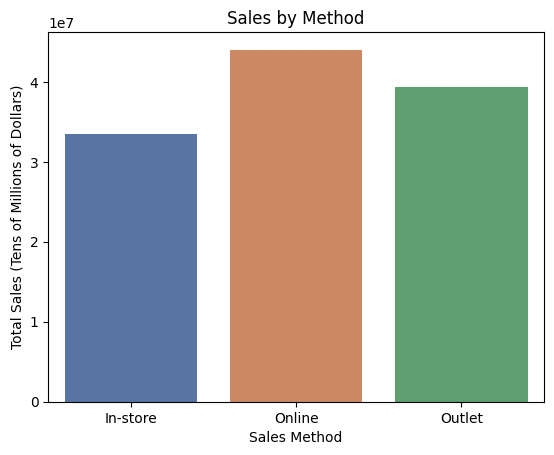

In [ ]:
#create a bar graph for sales method
sales_method_sales = combined_tables.groupby('SALES_METHOD')['sales_dollars'].sum()
sns.barplot(x=sales_method_sales.index,y=sales_method_sales.values, palette ='deep')
plt.title('Sales by Method')
plt.ylabel('Total Sales (Tens of Millions of Dollars)')
plt.xlabel('Sales Method')